# Dipole EM1 outside-training-region diagnostics

Notebook version of `test_strength_outside_train_region.py`.

The original script was a useful legacy diagnostic, but it used stale paths and the old `scrap.helper` API. This notebook keeps the same diagnostic flow while using the current generalized `helper_gpt`/`main_gpt2` artifacts:

- evaluate the emulator over the full available 160Yb parameter grid
- overlay emulated and true strength functions for a representative point
- compute global and per-sample strength errors
- compare true vs emulated `alphaD`
- color the parameter grid by emulator error and show the training-region rectangle

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import tensorflow as tf
from matplotlib.colors import LogNorm

# Locate the repository root no matter whether the notebook is launched from
# repo root, Dipole_polarizability/, or Dipole_polarizability/scrap/.
start = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [start, *start.parents]:
    if (candidate / "Dipole_polarizability").exists() and (candidate / "data/nuclear/160Yb_2d").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise RuntimeError("Could not find the SMLR repository root.")

DIPOLE_DIR = PROJECT_ROOT / "Dipole_polarizability"
sys.path.insert(0, str(DIPOLE_DIR / "src"))

import helper_gpt

plt.rcParams.update({"figure.dpi": 120})
print("Project root:", PROJECT_ROOT)
print("helper_gpt:", helper_gpt.__file__)

Project root: /Users/laurenjin/Documents/projects/SMLR/SMLR-jingy
helper_gpt: /Users/laurenjin/Documents/projects/SMLR/SMLR-jingy/Dipole_polarizability/src/helper_gpt.py


## Configuration

By default this uses `Dipole_polarizability/runs_em1`, which is where the dipole-specific paper reproduction artifacts live. Change `RUN_DIR` if you want to inspect another run.

In [2]:
RUN_DIR = DIPOLE_DIR / "runs_em1_random_070926"
if not (RUN_DIR / "best_params_global.txt").exists():
    RUN_DIR = PROJECT_ROOT / "runs_em1_random_070926"

STRENGTH_DIR = PROJECT_ROOT / "data/nuclear/160Yb_2d/total_strength"
ALPHAD_DIR = PROJECT_ROOT / "data/nuclear/160Yb_2d/total_alphaD"
STRENGTH_REGEX = r"strength_(?P<p2>[0-9.]+)_(?P<p1>[0-9.]+)\.out"
ALPHAD_REGEX = None

PARAMS_FILE = RUN_DIR / "best_params_global.txt"
SUMMARY_FILE = RUN_DIR / "run_summary.json"
summary = json.loads(SUMMARY_FILE.read_text()) if SUMMARY_FILE.exists() else {}

model = summary.get("model", {})
N = int(model.get("n", 13))
RETAIN = float(model.get("retain", 0.6))
ANSATZ = model.get("ansatz", "paper_dipole")
WIDTH_MODEL = model.get("width_model", "affine")
USE_VECTOR_TERMS = bool(model.get("use_vector_terms", True))
TRAIN_FILTER_RANGES = summary.get("train_filters")
if TRAIN_FILTER_RANGES is None:
    TRAIN_FILTER_RANGES = {"p1": [0.4, 1.8], "p2": [1.5, 4.0]}
SPLIT_MODE = summary.get("split_mode") or summary.get("args", {}).get("split_mode") or "range"
SPLIT_SEED = summary.get("split_seed") or summary.get("args", {}).get("split_seed")
CENTRAL_POINT = summary.get("central_point")

DETAIL_IDX = 46
SAVE_FIGS = False
FIG_DIR = RUN_DIR / "legacy_notebook_diagnostics"

print("Run dir:", RUN_DIR)
print("Params file:", PARAMS_FILE)
print("Model:", {"n": N, "retain": RETAIN, "ansatz": ANSATZ, "width_model": WIDTH_MODEL, "use_vector_terms": USE_VECTOR_TERMS})
print("Training filter ranges:", TRAIN_FILTER_RANGES)
print("Central point:", CENTRAL_POINT)

Run dir: /Users/laurenjin/Documents/projects/SMLR/SMLR-jingy/Dipole_polarizability/runs_em1_random_070926
Params file: /Users/laurenjin/Documents/projects/SMLR/SMLR-jingy/Dipole_polarizability/runs_em1_random_070926/best_params_global.txt
Model: {'n': 13, 'retain': 0.6, 'ansatz': 'paper_dipole', 'width_model': 'affine', 'use_vector_terms': True}
Training filter ranges: {}
Central point: [1.100000023841858, 2.75]


## Load full grid and train-region points

The legacy script evaluated all available grid points and then drew a rectangle around the training region. We do the same here: `dataset` is the full grid, while `train_param_values` only controls the rectangle overlay.

In [3]:
params = np.loadtxt(PARAMS_FILE).astype(np.float32)

dataset = helper_gpt.load_dataset(
    strength_dir=str(STRENGTH_DIR),
    alphaD_dir=str(ALPHAD_DIR),
    strength_regex=STRENGTH_REGEX,
    alphaD_regex=ALPHAD_REGEX,
    filter_ranges=None,
    central_point=CENTRAL_POINT,
)

train_param_file = RUN_DIR / "train_param_values.txt"
test_param_file = RUN_DIR / "test_param_values.txt"

if train_param_file.exists():
    train_param_values = np.loadtxt(train_param_file, dtype=np.float32)
    if train_param_values.ndim == 1:
        train_param_values = train_param_values[None, :]
else:
    # Fallback: reconstruct the training region from the summary filters.
    split = np.ones(len(dataset.param_values), dtype=bool)
    for name, bounds in TRAIN_FILTER_RANGES.items():
        col = dataset.param_names.index(name)
        lo, hi = map(float, bounds)
        split &= (dataset.param_values[:, col] >= lo) & (dataset.param_values[:, col] <= hi)
    train_param_values = dataset.param_values[split]

if test_param_file.exists():
    test_param_values = np.loadtxt(test_param_file, dtype=np.float32)
    if test_param_values.ndim == 1:
        test_param_values = test_param_values[None, :]
else:
    test_param_values = np.empty((0, dataset.param_values.shape[1]), dtype=np.float32)


def add_sampling_overlay(ax, *, label_prefix=""):
    """Show how points were sampled without misrepresenting random splits as a box."""
    if SPLIT_MODE == "random":
        if len(test_param_values):
            ax.scatter(
                test_param_values[:, 0], test_param_values[:, 1],
                marker="o", s=26, facecolors="none", edgecolors="black",
                linewidths=0.8, label=f"{label_prefix}test points",
            )
        ax.scatter(
            train_param_values[:, 0], train_param_values[:, 1],
            marker="x", s=28, c="black", linewidths=0.9,
            label=f"{label_prefix}train points",
        )
        ax.legend(frameon=False, loc="best", fontsize=8)
        return

    train_x = train_param_values[:, 0]
    train_y = train_param_values[:, 1]
    rect = patches.Rectangle(
        (float(np.min(train_x)), float(np.min(train_y))),
        float(np.max(train_x) - np.min(train_x)),
        float(np.max(train_y) - np.min(train_y)),
        linewidth=1.5,
        edgecolor="black",
        facecolor="none",
        label=f"{label_prefix}training region",
    )
    ax.add_patch(rect)
    ax.legend(frameon=False, loc="best", fontsize=8)

print("Full grid samples:", len(dataset.strengths))
print("Parameter names:", dataset.param_names)
print("Dataset central point:", dataset.central_point.tolist())
print("Training samples:", train_param_values.shape[0])
print("Test samples:", test_param_values.shape[0])
print("Split mode:", SPLIT_MODE)
print("Params shape:", params.shape)

Full grid samples: 225
Parameter names: ['p1', 'p2']
Dataset central point: [1.100000023841858, 2.75]
Training samples: 121
Test samples: 104
Split mode: random
Params shape: (330,)


## Emulator evaluation helpers

In [4]:
def coerce_params_layout(params_np, config):
    params_np = np.asarray(params_np, dtype=np.float32).reshape(-1)
    layout = helper_gpt.get_packed_layout(config)
    if params_np.size == layout.total_size:
        return params_np
    raise ValueError(f"Expected parameter vector of length {layout.total_size}, got {params_np.size}.")


def evaluate_emulator(dataset, params_np, n, retain, ansatz, width_model, use_vector_terms=True):
    config = helper_gpt.AnsatzConfig(
        n=n,
        n_params=int(dataset.param_values.shape[1]),
        ansatz=ansatz,
        width_model=width_model,
        use_vector_terms=use_vector_terms,
    )
    params_np = coerce_params_layout(params_np, config)

    param_values_tf = tf.convert_to_tensor(dataset.param_values, dtype=tf.float32)
    central_point_tf = tf.convert_to_tensor(dataset.central_point, dtype=tf.float32)
    params_tf = tf.convert_to_tensor(params_np, dtype=tf.float32)

    M_batch, v_batch, eta_batch, _ = helper_gpt.build_model_matrices_and_vectors(
        params=params_tf,
        config=config,
        param_values=param_values_tf,
        central_point=central_point_tf,
    )
    eigenvalues, eigenvectors = tf.linalg.eigh(M_batch)

    n_i = int(eigenvalues.shape[1])
    k_keep = max(1, min(int(round(retain * n_i)), n_i))
    left = (n_i - k_keep) // 2
    right = left + k_keep

    eigvals_kept = eigenvalues[:, left:right]
    eigvecs_kept = eigenvectors[:, :, left:right]
    proj = tf.matmul(tf.transpose(eigvecs_kept, perm=[0, 2, 1]), v_batch[:, :, None])
    B_batch = tf.square(tf.squeeze(proj, axis=-1))

    omega = dataset.strengths[0][:, 0].astype(np.float32)
    omega_tf = tf.convert_to_tensor(omega, dtype=tf.float32)

    strength_pred = []
    alphaD_pred = []
    eigs = []
    Bs = []
    for i in range(len(dataset.strengths)):
        y_pred = helper_gpt.give_me_Lorentzian(
            energy=omega_tf,
            poles=eigvals_kept[i],
            strength=B_batch[i],
            width=eta_batch[i],
        ).numpy()
        strength_pred.append(y_pred)
        eigs.append(eigvals_kept[i].numpy())
        Bs.append(B_batch[i].numpy())
        alphaD_pred.append(helper_gpt.calculate_alphaD(eigvals_kept[i].numpy(), B_batch[i].numpy()))

    return {
        "config": config,
        "omega": omega,
        "strength_pred": np.asarray(strength_pred),
        "alphaD_pred": np.asarray(alphaD_pred, dtype=float),
        "eigs": eigs,
        "Bs": Bs,
        "eta": eta_batch.numpy(),
    }

## Evaluate every grid point

In [5]:
outputs = evaluate_emulator(
    dataset=dataset,
    params_np=params,
    n=N,
    retain=RETAIN,
    ansatz=ANSATZ,
    width_model=WIDTH_MODEL,
    use_vector_terms=USE_VECTOR_TERMS,
)

strength_true = np.asarray([s[:, 1] for s in dataset.strengths], dtype=np.float32)
alphaD_true = np.asarray(dataset.alphaD_values, dtype=float)
alphaD_pred = outputs["alphaD_pred"]

strength_residual = outputs["strength_pred"] - strength_true
sample_rmse = np.sqrt(np.mean(strength_residual ** 2, axis=1))
sample_rel_l2 = np.linalg.norm(strength_residual, axis=1) / np.maximum(np.linalg.norm(strength_true, axis=1), 1e-12)
alphaD_rel_err = np.abs(alphaD_pred - alphaD_true) / np.maximum(np.abs(alphaD_true), 1e-12)

global_rmse = float(np.sqrt(np.sum(strength_residual ** 2)))
print("Global strength RMSE:", global_rmse)
print("Mean sample strength RMSE:", float(np.mean(sample_rmse)))
print("Mean relative strength L2:", float(np.mean(sample_rel_l2)))
print("Mean alphaD relative error:", float(np.mean(alphaD_rel_err)))
print("Max alphaD relative error:", float(np.max(alphaD_rel_err)))

Global strength RMSE: 31.879276275634766
Mean sample strength RMSE: 0.10499702394008636
Mean relative strength L2: 0.042399197816848755
Mean alphaD relative error: 0.0009375406989515625
Max alphaD relative error: 0.017315637226661407


## Representative strength function: emulator vs true

alphaD true / pred: 16.547191619873047 16.558420181274414
relative alphaD error: 0.0006785780729028226
eta: 2.3434572


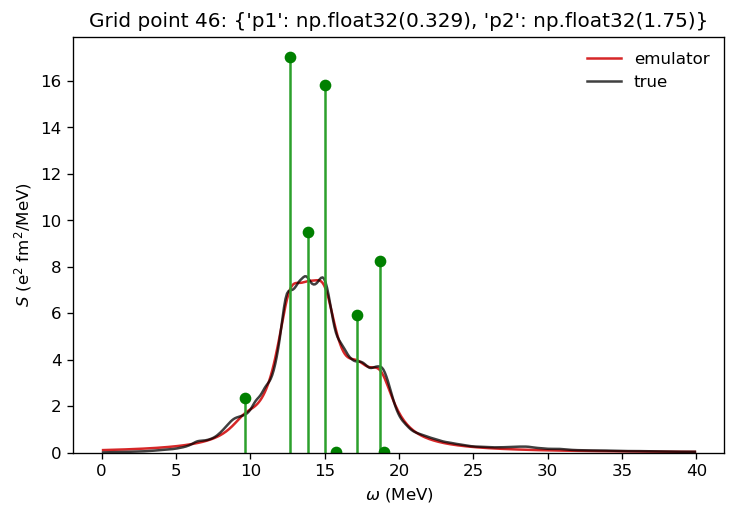

In [6]:
idx = min(DETAIL_IDX, len(dataset.strengths) - 1)
omega = dataset.strengths[idx][:, 0]
y_true = dataset.strengths[idx][:, 1]
y_pred = outputs["strength_pred"][idx]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(omega, y_pred, label="emulator", color="tab:red")
ax.plot(omega, y_true, label="true", color="black", alpha=0.75)
ax.stem(outputs["eigs"][idx], outputs["Bs"][idx], basefmt=" ", linefmt="tab:green", markerfmt="go")
ax.set_xlabel(r"$\omega$ (MeV)")
ax.set_ylabel(r"$S$ (e$^2$ fm$^2$/MeV)")
ax.set_title(f"Grid point {idx}: {dict(zip(dataset.param_names, dataset.param_values[idx]))}")
ax.set_ylim(bottom=0)
ax.legend(frameon=False)

print("alphaD true / pred:", alphaD_true[idx], alphaD_pred[idx])
print("relative alphaD error:", alphaD_rel_err[idx])
print("eta:", outputs["eta"][idx])

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / f"strength_overlay_row{idx}.png", bbox_inches="tight", dpi=200)

## Observable accuracy: true vs emulated `alphaD`

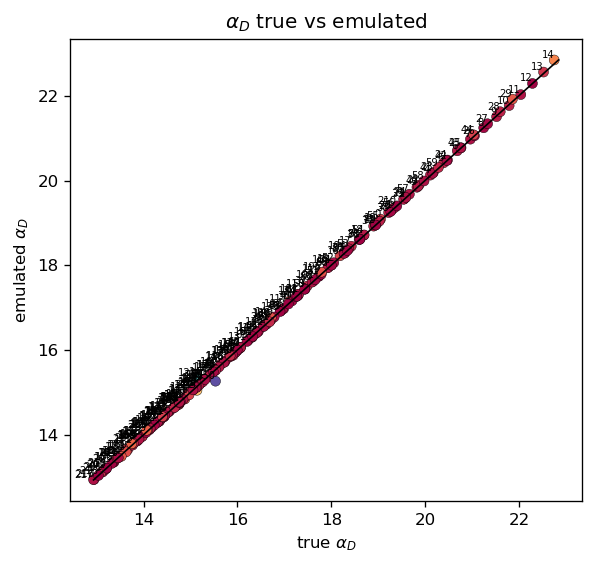

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(alphaD_true, alphaD_pred, c=alphaD_rel_err, cmap="Spectral", edgecolor="black", linewidth=0.25)
lo = min(np.min(alphaD_true), np.min(alphaD_pred))
hi = max(np.max(alphaD_true), np.max(alphaD_pred))
ax.plot([lo, hi], [lo, hi], color="black", lw=1)
ax.set_xlabel(r"true $\alpha_D$")
ax.set_ylabel(r"emulated $\alpha_D$")
ax.set_title(r"$\alpha_D$ true vs emulated")

if len(alphaD_true) <= 250:
    for i, (xv, yv) in enumerate(zip(alphaD_true, alphaD_pred)):
        ax.text(xv, yv, str(i), fontsize=6, ha="right", va="bottom")

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "alphaD_true_vs_pred.png", bbox_inches="tight", dpi=200)

## Parameter grid colored by `alphaD` relative error

For range-based sampling, the black rectangle marks the contiguous training region. For random sampling, the notebook marks the actual train points with black `x` markers and test points with open circles, because a bounding rectangle would incorrectly enclose most or all of the dataset.

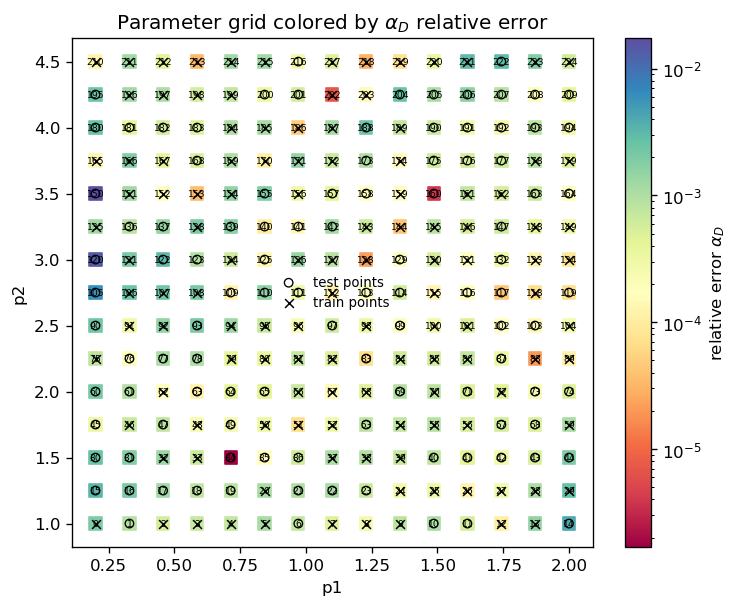

In [8]:
x = dataset.param_values[:, 0]
y = dataset.param_values[:, 1]
color = np.clip(alphaD_rel_err, 1e-12, None)

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(x, y, c=color, marker="s", cmap="Spectral", norm=LogNorm(), s=55)
fig.colorbar(sc, ax=ax, label=r"relative error $\alpha_D$")

if len(x) <= 250:
    for i, (xi, yi) in enumerate(zip(x, y)):
        ax.text(xi, yi, str(i), ha="center", va="center", fontsize=5.5, color="black")

add_sampling_overlay(ax)
ax.set_xlabel(dataset.param_names[0])
ax.set_ylabel(dataset.param_names[1])
ax.set_title(r"Parameter grid colored by $\alpha_D$ relative error")

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "parameter_grid_alphaD_relerr.png", bbox_inches="tight", dpi=200)

## Parameter grid colored by strength relative L2 error

The legacy script had this as a commented alternative. It is useful when a model gets the observable right but misses spectral shape.

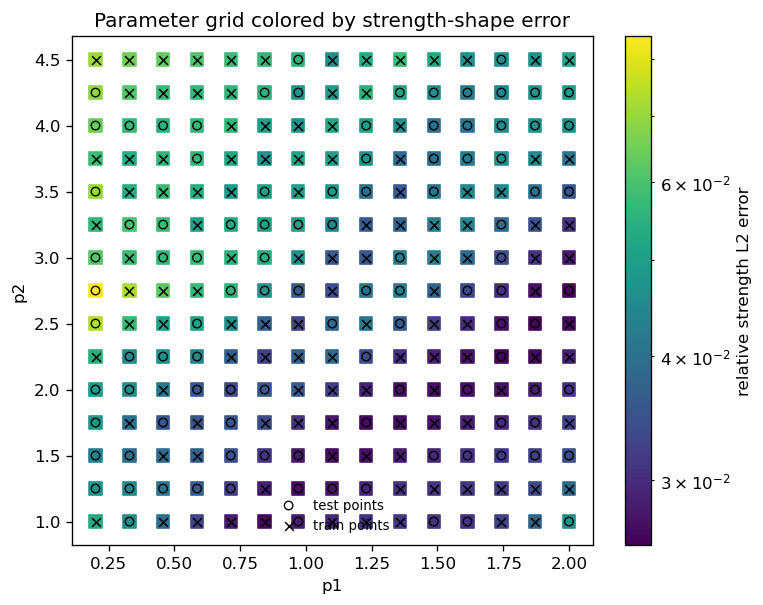

In [9]:
color = np.clip(sample_rel_l2, 1e-12, None)

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(x, y, c=color, marker="s", cmap="viridis", norm=LogNorm(), s=55)
fig.colorbar(sc, ax=ax, label="relative strength L2 error")

add_sampling_overlay(ax)
ax.set_xlabel(dataset.param_names[0])
ax.set_ylabel(dataset.param_names[1])
ax.set_title("Parameter grid colored by strength-shape error")

if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "parameter_grid_strength_rel_l2.png", bbox_inches="tight", dpi=200)